# ML Models for IDC Trading

The previous notebooks showed how to write trading algorithms that use signals
(CSV time-series of forecasts) to make decisions. This notebook takes the next
step: **a trained machine-learning model inside a live IDC algo**.

We will build a model that predicts the near-term mid-price of an intraday
product from order book features, export it to ONNX, register it with
nexa-backtest, and use it from within an IDC algo to decide *when* to buy.

**What you will learn**

- Why a simple timing model can add value in IDC markets
- How to engineer features from a live order book
- How to train a scikit-learn model and export it to ONNX
- How `ONNXModel`, `ModelRegistry`, and `ctx.predict()` fit together
- How to write an IDC algo that calls a model on every bar
- The look-ahead bias trap in ML feature engineering and how to avoid it

**Prerequisites:** Notebooks 01 (DA basics) and 02 (IDC mechanics). This
notebook also requires the `ml` extra and `scikit-learn` + `skl2onnx` for
the training section:

    pip install nexa-backtest[ml] scikit-learn skl2onnx

---

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')  # suppress minor deprecation noise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
from decimal import Decimal
import tempfile

# Paths relative to the notebooks/ directory
FIXTURES_DIR = Path('../tests/fixtures')
IDC_DATA_DIR = FIXTURES_DIR / 'nordpool'

# Temporary directory for model files generated during this tutorial
MODEL_DIR  = Path(tempfile.mkdtemp())
MODEL_PATH = MODEL_DIR / 'idc_price_model.onnx'

print('IDC fixture directory:', IDC_DATA_DIR.resolve())
print('Temporary model directory:', MODEL_DIR)
print('All paths exist:', IDC_DATA_DIR.exists())

IDC fixture directory: /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures/nordpool
Temporary model directory: /var/folders/t7/zj98q0q10hjdswg08sc9xsl80000gp/T/tmpfpv1dwet
All paths exist: True


---

## Part 1 — The Challenge: When Should You Buy?

In IDC trading you can submit, modify, and cancel orders continuously from
when the market opens until gate closure (30 minutes before delivery in Nord
Pool). This is very different from the Day-Ahead auction, where you place one
bid and wait for a single clearing price.

That flexibility creates a question: **is now a good time to buy, or should
I wait for a better price?**

The `BestAskBuyerAlgo` from notebook 02 always buys at the best ask. It always
gets filled, but sometimes it buys just before a price drop — it would have
been cheaper to wait.

A machine-learning model can try to do better: observe the current order book
state, compare it to historical patterns, and estimate whether the price is
likely to be higher or lower in the next few minutes. Let us first see how
prices actually move during an IDC session.

In [2]:
# Load the IDC fixture: one day of synthetic Nord Pool order book events
idc_events = pd.read_parquet(IDC_DATA_DIR / 'idc_events' / 'NO1_2026_03.parquet')

print(f'Rows: {len(idc_events):,}')
print(f'Columns: {list(idc_events.columns)}')
print(f'Date range: {idc_events["timestamp"].min()} to {idc_events["timestamp"].max()}')
print(f'Products:   {sorted(idc_events["product_id"].unique())}')
print()

# Focus on one product for the exploration section
PRODUCT  = 'NO1-QH-0800'  # delivers 08:00-08:15 UTC; gate closes at 07:30
p_events = idc_events[idc_events['product_id'] == PRODUCT].sort_values('timestamp')
p_trades = p_events[p_events['event_type'] == 'trade']

print(f'Product {PRODUCT}:')
print(f'  Total events:  {len(p_events)}')
print(f'  New orders:    {(p_events["event_type"]=="new").sum()}')
print(f'  Cancellations: {(p_events["event_type"]=="cancel").sum()}')
print(f'  Trades:        {(p_events["event_type"]=="trade").sum()}')
print(f'  Price range:   {p_trades["price_eur_mwh"].min():.2f} to '
      f'{p_trades["price_eur_mwh"].max():.2f} EUR/MWh')

Rows: 3,600
Columns: ['timestamp', 'event_type', 'order_id', 'zone', 'product_id', 'side', 'price_eur_mwh', 'volume_mw', 'remaining_mw', 'aggressor_side', 'trade_id']
Date range: 2026-03-01 00:00:00+00:00 to 2026-03-01 23:58:48+00:00
Products:   ['NO1-QH-0800', 'NO1-QH-0815', 'NO1-QH-0830']

Product NO1-QH-0800:
  Total events:  1200
  New orders:    566
  Cancellations: 248
  Trades:        386
  Price range:   45.90 to 54.60 EUR/MWh


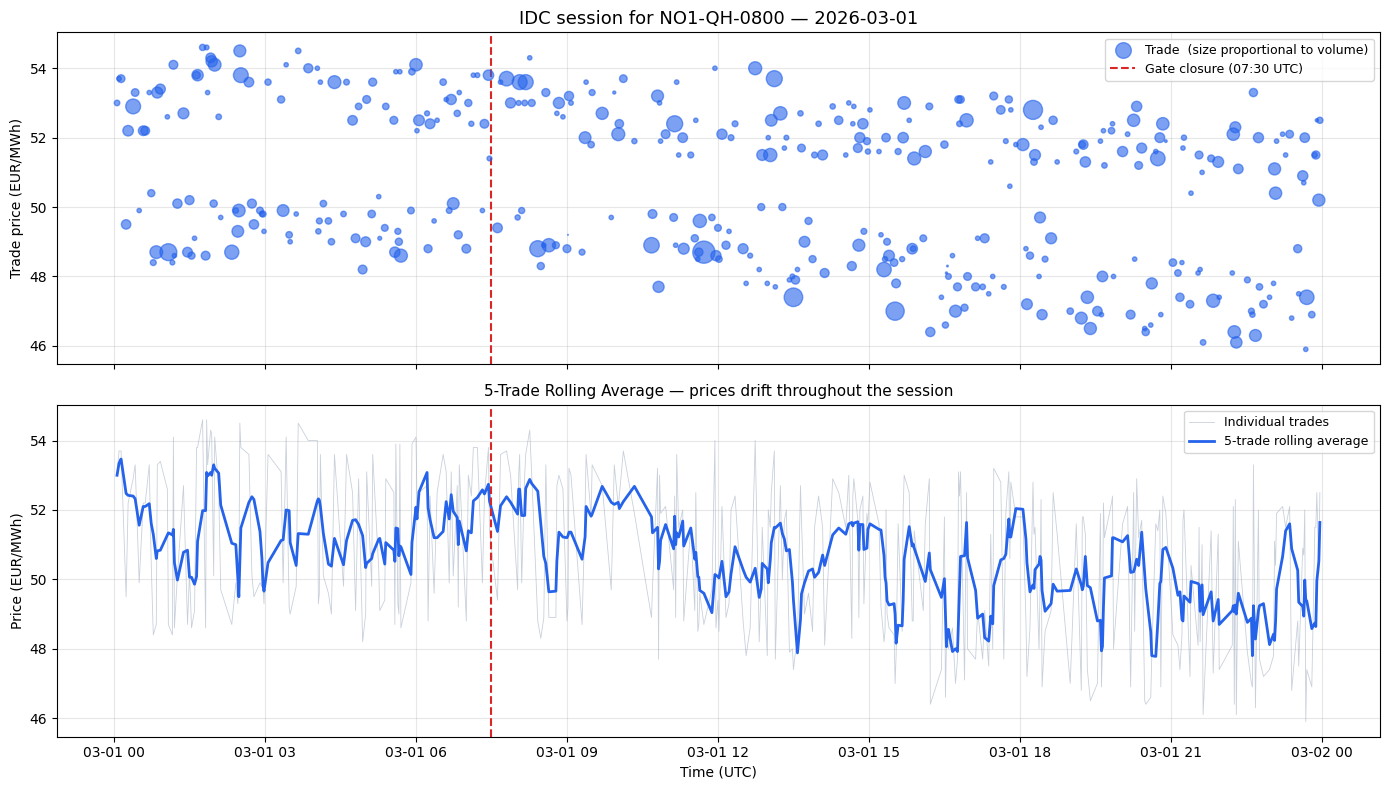

Observation: prices drift throughout the session.
A model that predicts short-term price direction could help decide
when to buy — and when to wait for a cheaper entry.


In [3]:
gate_close = pd.Timestamp('2026-03-01 07:30:00', tz='UTC')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: individual trade prices (dot size proportional to volume)
ax1 = axes[0]
ax1.scatter(
    p_trades['timestamp'], p_trades['price_eur_mwh'],
    s=p_trades['volume_mw'] * 20, alpha=0.6, color='#2563eb', zorder=3,
    label='Trade  (size proportional to volume)',
)
ax1.axvline(gate_close, color='#dc2626', linewidth=1.5, linestyle='--',
            label='Gate closure (07:30 UTC)')
ax1.set_title(f'IDC session for {PRODUCT} — 2026-03-01', fontsize=13)
ax1.set_ylabel('Trade price (EUR/MWh)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: 5-trade rolling average to highlight the trend
ax2 = axes[1]
p_sorted = p_trades.sort_values('timestamp').copy()
p_sorted['rolling_avg'] = p_sorted['price_eur_mwh'].rolling(window=5, min_periods=1).mean()
ax2.plot(p_sorted['timestamp'], p_sorted['price_eur_mwh'],
         color='#94a3b8', linewidth=0.6, alpha=0.5, label='Individual trades')
ax2.plot(p_sorted['timestamp'], p_sorted['rolling_avg'],
         color='#2563eb', linewidth=2, label='5-trade rolling average')
ax2.axvline(gate_close, color='#dc2626', linewidth=1.5, linestyle='--')
ax2.set_ylabel('Price (EUR/MWh)')
ax2.set_xlabel('Time (UTC)')
ax2.set_title('5-Trade Rolling Average — prices drift throughout the session', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Observation: prices drift throughout the session.')
print('A model that predicts short-term price direction could help decide')
print('when to buy — and when to wait for a cheaper entry.')

---

## Part 2 — The ML Workflow

Here is the big picture of what we are going to build:

```
Historical IDC data
        |
        v
  Feature engineering       <- reconstruct order book at each bar;
  (offline, in this notebook)   extract: hour_frac, spread, imbalance
        |
        v
  Train sklearn model       <- LinearRegression: predict next mid-price
        |
        v
  Export to ONNX            <- portable, safe, fast C++ runtime
        |
        v
  Register ONNXModel        <- ModelRegistry holds named models
        |
        v
  Algo calls ctx.predict()  <- same interface in backtest, paper, live
        |
        v
  Prediction: next mid-price -> buy now or wait?
```

The key design rule: **the algo never knows whether it is in backtest or
production**. It calls `ctx.predict()` and gets back a dict. The engine
handles everything else.

---

## Part 3 — Engineering Features from the Order Book

A machine-learning model needs **features**: numbers that describe the current
state of the market. We need features that are:

1. Available at the moment the algo runs — no peeking into the future
2. Also computable at runtime via `ctx` methods
3. Plausibly predictive of short-term price direction

| Feature | Source in algo | Intuition |
|---|---|---|
| `hour_frac` | `ctx.current_time` | Intraday seasonality: prices tend to drift as the session progresses |
| `spread_eur_mwh` | `ctx.get_best_ask()` − `ctx.get_best_bid()` | Wide spread = uncertain, thin liquidity |
| `imbalance` | bid depth ÷ total depth | More buyers than sellers suggests upward pressure |
| `time_to_gate_mins` | `ctx.time_to_gate_closure()` | Urgency: volatility often spikes near gate closure |

To build training data we **replay the historical order book**: process events
in timestamp order and every 5 minutes take a snapshot of the book state.
That snapshot becomes one row in the training dataset.

This is exactly what the backtest engine does for the algo at runtime — we are
doing it offline here to generate labelled training data.

In [4]:
def build_snapshots(
    events_df: pd.DataFrame,
    product_id: str,
    interval_mins: int = 5,
) -> pd.DataFrame:
    """Reconstruct the order book state at regular intervals.

    Replays all events for `product_id` in timestamp order. At each
    interval boundary, extracts features from the current book state.
    Returns one row per snapshot.
    """
    product_events = (
        events_df[events_df['product_id'] == product_id]
        .sort_values('timestamp')
    )

    # Parse delivery start from product_id, e.g. 'NO1-QH-0800' -> 08:00
    hhmm = product_id.split('-')[2]
    delivery_hour = int(hhmm[:2])
    delivery_min  = int(hhmm[2:])
    base_date    = product_events['timestamp'].min().normalize()
    delivery_dt  = base_date + pd.Timedelta(hours=delivery_hour, minutes=delivery_min)
    gate_closure = delivery_dt - pd.Timedelta(minutes=30)  # Nord Pool: 30 min before

    book: dict[str, dict] = {}   # order_id -> {side, price, remaining}
    snapshots: list[dict] = []
    event_list = product_events.to_dict('records')
    event_idx  = 0
    start = product_events['timestamp'].min().floor('min')

    for snap_time in pd.date_range(start, gate_closure, freq=f'{interval_mins}min'):
        # Step the book forward to snap_time
        while (
            event_idx < len(event_list)
            and event_list[event_idx]['timestamp'] <= snap_time
        ):
            ev  = event_list[event_idx]
            oid = ev['order_id']
            if ev['event_type'] == 'new':
                book[oid] = {
                    'side':      ev['side'],
                    'price':     ev['price_eur_mwh'],
                    'remaining': ev['remaining_mw'],
                }
            elif ev['event_type'] == 'cancel':
                book.pop(oid, None)
            elif ev['event_type'] == 'trade' and oid in book:
                book[oid]['remaining'] = ev['remaining_mw']
                if ev['remaining_mw'] == 0:
                    del book[oid]
            event_idx += 1

        bids = [(v['price'], v['remaining']) for v in book.values() if v['side'] == 'buy']
        asks = [(v['price'], v['remaining']) for v in book.values() if v['side'] == 'sell']
        if not bids or not asks:
            continue  # book is empty - skip this snapshot

        best_bid = max(p for p, _ in bids)
        best_ask = min(p for p, _ in asks)
        if best_bid >= best_ask:
            continue  # crossed book - should not happen in real data

        mid       = (best_bid + best_ask) / 2.0
        spread    = best_ask - best_bid
        bid_depth = sum(v for _, v in bids)
        ask_depth = sum(v for _, v in asks)
        total     = bid_depth + ask_depth
        imbalance = bid_depth / total if total > 0 else 0.5

        hour_frac = snap_time.hour + snap_time.minute / 60.0
        ttg_mins  = max(0.0, (gate_closure - snap_time).total_seconds() / 60.0)

        snapshots.append({
            'timestamp':         snap_time,
            'product_id':        product_id,
            'best_bid':          best_bid,
            'best_ask':          best_ask,
            'mid_price':         mid,
            'spread_eur_mwh':    spread,
            'bid_depth_mw':      bid_depth,
            'ask_depth_mw':      ask_depth,
            'imbalance':         imbalance,
            'hour_frac':         hour_frac,
            'time_to_gate_mins': ttg_mins,
        })

    return pd.DataFrame(snapshots)


# Build snapshots for all three products and combine
products  = sorted(idc_events['product_id'].unique())
all_snaps = pd.concat(
    [build_snapshots(idc_events, pid) for pid in products],
    ignore_index=True,
).sort_values(['product_id', 'timestamp'])

# Label: what will the mid-price be at the NEXT snapshot (5 min later)?
# shift(-1) within each product prevents cross-product label leakage.
all_snaps['next_mid'] = all_snaps.groupby('product_id')['mid_price'].shift(-1)
all_snaps = all_snaps.dropna(subset=['next_mid']).copy()

print(f'Total snapshots (training rows): {len(all_snaps)}')
print()
print(all_snaps[
    ['hour_frac', 'spread_eur_mwh', 'imbalance', 'time_to_gate_mins', 'mid_price', 'next_mid']
].describe().round(3).to_string())

Total snapshots (training rows): 269

       hour_frac  spread_eur_mwh  imbalance  time_to_gate_mins  mid_price  next_mid
count    269.000         269.000    269.000            269.000    269.000   269.000
mean       3.968           2.065      0.417            227.305     50.999    51.005
std        2.177           0.822      0.140            130.739      1.291     1.302
min        0.083           0.800      0.024              5.000     49.200    49.200
25%        2.083           1.400      0.371            115.000     49.750    49.750
50%        4.000           1.900      0.431            225.000     51.250    51.250
75%        5.833           2.500      0.486            340.000     51.800    51.950
max        7.917           5.300      0.912            475.000     53.450    53.450


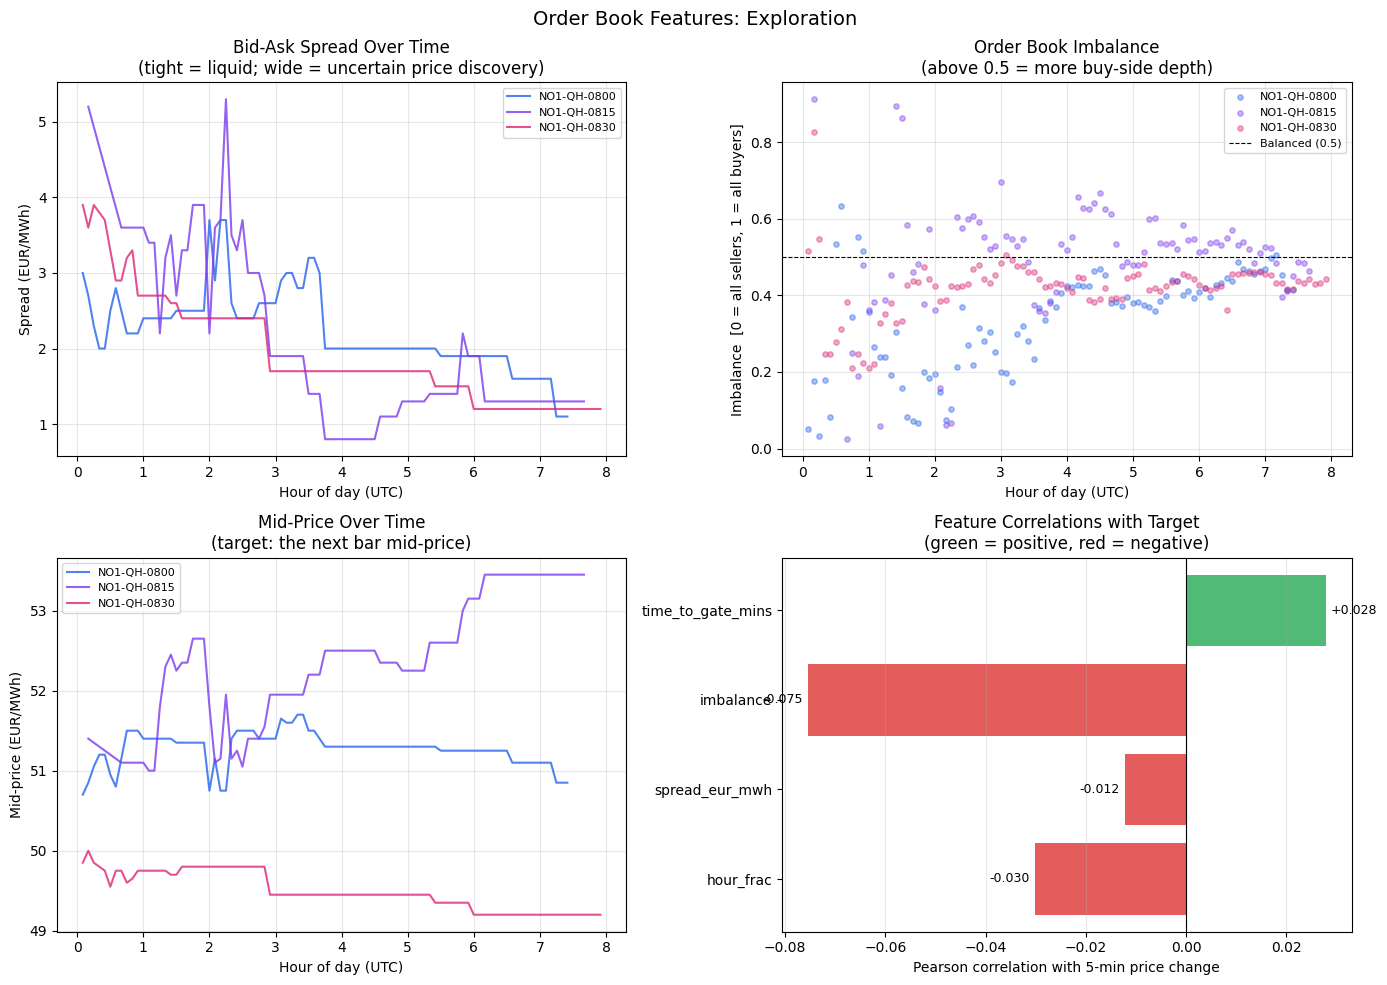

Feature correlations with the 5-minute price change:
  hour_frac                 -0.0301  ███
  spread_eur_mwh            -0.0122  █
  imbalance                 -0.0754  ███████
  time_to_gate_mins         +0.0279  ██


In [5]:
product_colors = {
    'NO1-QH-0800': '#2563eb',
    'NO1-QH-0815': '#7c3aed',
    'NO1-QH-0830': '#db2777',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Order Book Features: Exploration', fontsize=14)

# Panel 1: spread over time (does liquidity change during the session?)
ax1 = axes[0, 0]
for pid, grp in all_snaps.groupby('product_id'):
    ax1.plot(grp['hour_frac'], grp['spread_eur_mwh'],
             color=product_colors[pid], linewidth=1.5, alpha=0.8, label=pid)
ax1.set_xlabel('Hour of day (UTC)')
ax1.set_ylabel('Spread (EUR/MWh)')
ax1.set_title('Bid-Ask Spread Over Time\n(tight = liquid; wide = uncertain price discovery)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: order book imbalance (is there more buy or sell pressure?)
ax2 = axes[0, 1]
for pid, grp in all_snaps.groupby('product_id'):
    ax2.scatter(grp['hour_frac'], grp['imbalance'],
                color=product_colors[pid], alpha=0.4, s=15, label=pid)
ax2.axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='Balanced (0.5)')
ax2.set_xlabel('Hour of day (UTC)')
ax2.set_ylabel('Imbalance  [0 = all sellers, 1 = all buyers]')
ax2.set_title('Order Book Imbalance\n(above 0.5 = more buy-side depth)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: mid-price over time (this is what we want to predict)
ax3 = axes[1, 0]
for pid, grp in all_snaps.groupby('product_id'):
    ax3.plot(grp['hour_frac'], grp['mid_price'],
             color=product_colors[pid], linewidth=1.5, alpha=0.8, label=pid)
ax3.set_xlabel('Hour of day (UTC)')
ax3.set_ylabel('Mid-price (EUR/MWh)')
ax3.set_title('Mid-Price Over Time\n(target: the next bar mid-price)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: feature correlations with the 5-min price change
all_snaps['price_change'] = all_snaps['next_mid'] - all_snaps['mid_price']
feature_cols = ['hour_frac', 'spread_eur_mwh', 'imbalance', 'time_to_gate_mins']
corrs = all_snaps[feature_cols + ['price_change']].corr()['price_change'][:-1]

ax4 = axes[1, 1]
bar_colors = ['#16a34a' if c > 0 else '#dc2626' for c in corrs.values]
ax4.barh(corrs.index, corrs.values, color=bar_colors, alpha=0.75)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Pearson correlation with 5-min price change')
ax4.set_title('Feature Correlations with Target\n(green = positive, red = negative)')
ax4.grid(True, alpha=0.3, axis='x')
for i, (feat, c) in enumerate(corrs.items()):
    ax4.text(c + (0.001 if c >= 0 else -0.001), i, f'{c:+.3f}',
             va='center', ha='left' if c >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('Feature correlations with the 5-minute price change:')
for feat, c in corrs.items():
    bar = chr(9608) * int(abs(c) * 100)
    print(f'  {feat:<25} {c:+.4f}  {bar}')

---

## Part 4 — Training the Model

### The critical rule: never shuffle a financial time series

With image or customer data it is standard practice to shuffle and split
randomly. **Never do this with financial time series.**

You are trying to predict the future from the past. If your test set contains
data from 00:30 and your training set contains data from 06:00, the model has
learned from the future. It looks great in evaluation but fails in production
— look-ahead bias at the model-training level.

```
WRONG: shuffle, then split
   mixed:  [06:15] [03:45] [01:30] [05:00] ...
            ^ train                  ^ test
   (training data from the future of the test data!)

RIGHT: chronological split
   sorted: [00:00] -> [04:00] | [04:00] -> [07:30]
            <-- train set -->  | <--  test set  -->
```

We train on the early session (00:00–04:00) and test on the late session
(04:00–07:30), which is the critical pre-gate-closure window.

### Feature choice

The correlation chart shows `hour_frac` has the clearest relationship with
near-term price changes. It captures the intraday drift visible in the price
chart: mid-prices tend to move as the session advances toward gate closure.

For this tutorial we use **`hour_frac` as the sole feature**. This keeps the
ONNX export simple and the model easy to inspect. In production you would add
more features (spread, imbalance, recent trade momentum) using a combined
multi-column input tensor.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

FEATURE    = 'hour_frac'
TARGET     = 'next_mid'
SPLIT_HOUR = 4.0  # 04:00 UTC

train_df = all_snaps[all_snaps['hour_frac'] <  SPLIT_HOUR].copy()
test_df  = all_snaps[all_snaps['hour_frac'] >= SPLIT_HOUR].copy()

X_train = train_df[[FEATURE]].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)
X_test  = test_df[[FEATURE]].values.astype(np.float32)
y_test  = test_df[TARGET].values.astype(np.float32)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print(f'Model: LinearRegression  |  Feature: {FEATURE}')
print(f'  Coefficient : {model.coef_[0]:+.4f} EUR/MWh per additional hour')
print(f'  Intercept   : {model.intercept_:+.4f} EUR/MWh')
print()
print(f'Train period 00:00-{SPLIT_HOUR:.0f}:00  ({len(train_df)} snapshots)  MAE: {mae_train:.4f} EUR/MWh')
print(f'Test  period {SPLIT_HOUR:.0f}:00-07:30  ({len(test_df)} snapshots)  MAE: {mae_test:.4f} EUR/MWh  R²: {r2_test:.4f}')

Model: LinearRegression  |  Feature: hour_frac
  Coefficient : +0.1180 EUR/MWh per additional hour
  Intercept   : +50.6526 EUR/MWh

Train period 00:00-4:00  (134 snapshots)  MAE: 0.8583 EUR/MWh
Test  period 4:00-07:30  (135 snapshots)  MAE: 1.3276 EUR/MWh  R²: -0.0297


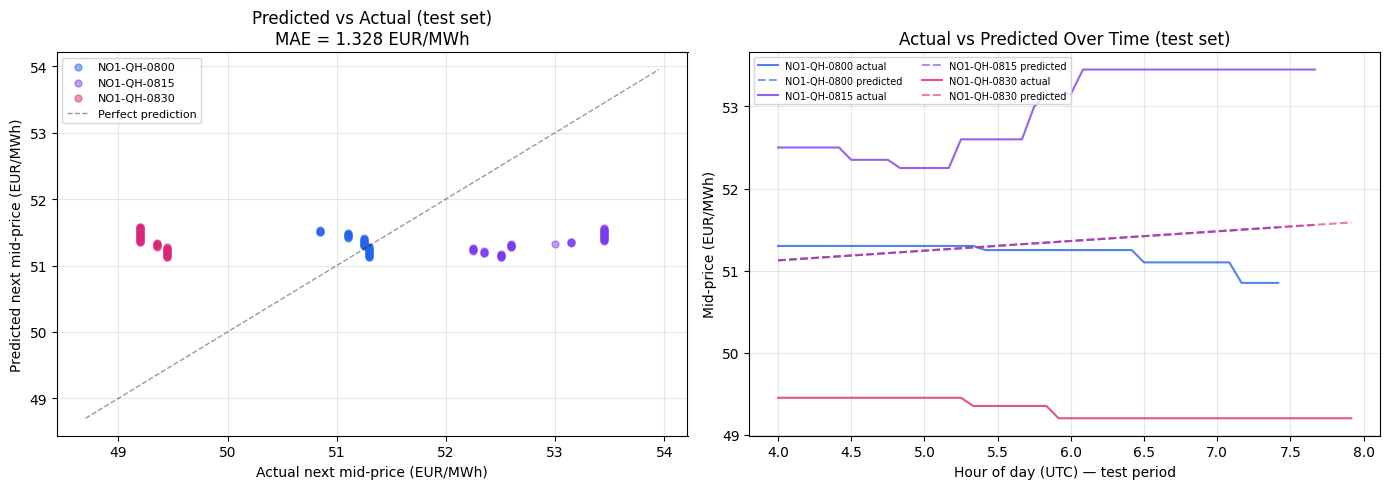

A linear model on one feature gives MAE ~ 1.33 EUR/MWh.
Typical IDC spreads are 0.3-1.5 EUR/MWh, so this is a weak signal.
It is enough to demonstrate the full pipeline. Production models would use:
  - Months of data, not one day
  - More features (spread, imbalance, recent trade momentum)
  - A non-linear model (gradient boosting, small neural net)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: predicted vs actual scatter (test set)
ax1 = axes[0]
for pid, grp in test_df.groupby('product_id'):
    idx = (test_df['product_id'] == pid).values
    ax1.scatter(y_test[idx], y_pred_test[idx],
                color=product_colors[pid], alpha=0.5, s=25, label=pid)
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
ax1.plot(lims, lims, 'k--', linewidth=1, alpha=0.4, label='Perfect prediction')
ax1.set_xlabel('Actual next mid-price (EUR/MWh)')
ax1.set_ylabel('Predicted next mid-price (EUR/MWh)')
ax1.set_title(f'Predicted vs Actual (test set)\nMAE = {mae_test:.3f} EUR/MWh')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: actual and predicted over time (test set)
ax2 = axes[1]
for pid, grp in test_df.groupby('product_id'):
    idx = (test_df['product_id'] == pid).values
    ax2.plot(grp['hour_frac'], y_test[idx],
             color=product_colors[pid], linewidth=1.5, alpha=0.8, label=f'{pid} actual')
    ax2.plot(grp['hour_frac'], y_pred_test[idx],
             color=product_colors[pid], linewidth=1.5, linestyle='--', alpha=0.6,
             label=f'{pid} predicted')
ax2.set_xlabel('Hour of day (UTC) — test period')
ax2.set_ylabel('Mid-price (EUR/MWh)')
ax2.set_title('Actual vs Predicted Over Time (test set)')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'A linear model on one feature gives MAE ~ {mae_test:.2f} EUR/MWh.')
print('Typical IDC spreads are 0.3-1.5 EUR/MWh, so this is a weak signal.')
print('It is enough to demonstrate the full pipeline. Production models would use:')
print('  - Months of data, not one day')
print('  - More features (spread, imbalance, recent trade momentum)')
print('  - A non-linear model (gradient boosting, small neural net)')

---

## Part 5 — Exporting to ONNX

We have a trained scikit-learn model. We need to package it in a format that
nexa-backtest can load safely and efficiently.

### Why ONNX and not pickle?

| | pickle / joblib | ONNX |
|---|---|---|
| **Security** | Executes arbitrary Python on load | Safe: no Python code |
| **Portability** | sklearn-specific | PyTorch, TF, XGBoost, sklearn all export to it |
| **Runtime speed** | Python interpreter | Compiled C++ via `onnxruntime` |
| **Hosted environment** | Security risk | Safe |

nexa-backtest supports both formats via `ONNXModel` and `SklearnModel`, but
ONNX is strongly recommended for anything that will run in production.

### What `skl2onnx` does

`skl2onnx` converts a fitted sklearn estimator into an ONNX computational
graph: a sequence of mathematical operations (matrix multiplications,
additions) with no Python. It runs via the `onnxruntime` C++ library.

One quirk: `skl2onnx` names the output tensor `'variable'` by default for
regression models. Production models built with PyTorch or XGBoost let you
choose descriptive names. We use `'variable'` as-is for this tutorial.

In [8]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# One named input: 'hour_frac', shape [batch_size, 1].
# None means the batch dimension is flexible; we always use batch_size = 1.
initial_types = [('hour_frac', FloatTensorType([None, 1]))]

onnx_proto = convert_sklearn(model, initial_types=initial_types, target_opset=15)

with open(MODEL_PATH, 'wb') as f:
    f.write(onnx_proto.SerializeToString())

print(f'Model saved: {MODEL_PATH}')
print(f'File size:   {MODEL_PATH.stat().st_size} bytes')
print()

# Verify the ONNX graph directly with onnxruntime before registering with nexa-backtest
import onnxruntime as ort

session = ort.InferenceSession(str(MODEL_PATH))

print('ONNX model inputs:')
for inp in session.get_inputs():
    print(f'  {inp.name}: shape={inp.shape}, type={inp.type}')

print('ONNX model outputs:')
for out in session.get_outputs():
    print(f'  {out.name}: shape={out.shape}, type={out.type}')

# Manual test inference at 06:30 UTC
test_in = np.array([[6.5]], dtype=np.float32)
raw_out = session.run(None, {'hour_frac': test_in})
print(f'\nDirect ONNX inference at hour_frac=6.5: {raw_out[0][0][0]:.4f} EUR/MWh')

Model saved: /var/folders/t7/zj98q0q10hjdswg08sc9xsl80000gp/T/tmpfpv1dwet/idc_price_model.onnx
File size:   266 bytes

ONNX model inputs:
  hour_frac: shape=[None, 1], type=tensor(float)
ONNX model outputs:
  variable: shape=[None, 1], type=tensor(float)

Direct ONNX inference at hour_frac=6.5: 51.4198 EUR/MWh


---

## Part 6 — The nexa-backtest ML API

Three components work together:

| Component | Role |
|---|---|
| `ONNXModel` | Wraps the `.onnx` file; handles type conversion, lazy loading, schema validation |
| `ModelRegistry` | Holds named models; the algo looks models up by name at inference time |
| `ctx.predict()` | The algo's entry point; identical call in backtest, paper, and live modes |

### Lazy loading

The ONNX file is not loaded when you create an `ONNXModel` or call
`registry.register()`. Loading happens on the first `predict()` or
`validate()` call. This keeps startup fast even with many registered models.

### Automatic type conversion

`ONNXModel.predict()` accepts a plain Python dict — no numpy in the algo:

```python
# In your algo's on_bar():
result = ctx.predict('idc_price_model', {'hour_frac': 6.5})  # float -> np.float32
predicted_price = result['variable']                          # np.ndarray -> float
```

### The output name `'variable'`

This is `skl2onnx`'s default for regression models. In production, build your
ONNX graph with meaningful output names (using PyTorch or the ONNX graph API)
so that `result['price_forecast']` reads more naturally than `result['variable']`.

In [9]:
from nexa_backtest.models.onnx import ONNXModel

# Create the wrapper with the same input/output names as the ONNX graph
price_model = ONNXModel(
    name='idc_price_model',
    path=MODEL_PATH,
    input_schema={'hour_frac': float},  # feature name -> Python type
    output_schema={'variable': float},  # output name -> Python type
)

# --- Single prediction ---
result = price_model.predict({'hour_frac': 6.5})  # 06:30 UTC
print(f"predict({{'hour_frac': 6.5}}) -> {result}")
print(f"Predicted next mid-price at 06:30: {result['variable']:.4f} EUR/MWh")
print()

# --- validate(): load the file and check schema compatibility ---
val = price_model.validate()
print('Validation result:')
print(f'  model_name:     {val.model_name}')
print(f'  valid:          {val.valid}')
print(f'  load_time_ms:   {val.load_time_ms}')
print(f'  actual_inputs:  {val.actual_inputs}')
print(f'  actual_outputs: {val.actual_outputs}')
print(f'  error:          {val.error}')

predict({'hour_frac': 6.5}) -> {'variable': 51.41982650756836}
Predicted next mid-price at 06:30: 51.4198 EUR/MWh

Validation result:
  model_name:     idc_price_model
  valid:          True
  load_time_ms:   0
  actual_inputs:  ['hour_frac']
  actual_outputs: ['variable']
  error:          None


In [10]:
from nexa_backtest.models.registry import ModelRegistry

registry = ModelRegistry()
registry.register(price_model)

print('Registered models:', registry.list_models())
print()

# validate_all() loads every model and checks schema compatibility.
# Call this before starting a backtest to catch file-not-found and
# schema mismatch errors before the first on_bar() call.
all_results = registry.validate_all()

for r in all_results:
    status = 'VALID' if r.valid else f'INVALID: {r.error}'
    print(f'{r.model_name}: {status}')
    print(f'  Inputs:   {r.actual_inputs}')
    print(f'  Outputs:  {r.actual_outputs}')
    print(f'  Loaded in {r.load_time_ms} ms')

Registered models: ['idc_price_model']

idc_price_model: VALID
  Inputs:   ['hour_frac']
  Outputs:  ['variable']
  Loaded in 0 ms


---

## Part 7 — Writing the ML-Driven IDC Algo

We will write two algos and compare them:

| Algo | Strategy |
|---|---|
| `NaiveAlgo` | Buy 1 MW at the best ask on every bar, no model (the baseline) |
| `MLAlgo` | Only buy when the model predicts the price will rise |

The `MLAlgo` decision rule on each bar:

```
1. Get the current best ask price from ctx
2. Call ctx.predict('idc_price_model', {'hour_frac': ...})
3. If current_ask < predicted_next_mid - THRESHOLD:
       buy now  (price expected to rise; current ask is a cheap entry)
   else:
       skip     (price may fall or be flat; wait for a better entry)
```

`THRESHOLD` controls selectivity. Too high means almost never buying; too
low means buying as often as the naive algo. In production you would tune
this on a validation period held out from both train and test.

In [11]:
from nexa_backtest import SimpleAlgo, Order, BacktestEngine
from nexa_backtest.context import TradingContext
from nexa_backtest.types import Fill


class NaiveAlgo(SimpleAlgo):
    """Baseline: buy 1 MW at the best ask on every bar, no model."""

    PRODUCTS = ['NO1-QH-0800', 'NO1-QH-0815', 'NO1-QH-0830']

    def on_setup(self, ctx: TradingContext) -> None:
        self.fill_count = 0

    def on_bar(self, ctx: TradingContext) -> None:
        for product_id in self.PRODUCTS:
            # Stop trading 5 minutes before gate closure
            if ctx.time_to_gate_closure(product_id).total_seconds() < 300:
                continue

            ask = ctx.get_best_ask(product_id)
            if ask is None:
                continue

            # Bid 1 EUR above the ask to guarantee an immediate fill
            ctx.place_order(Order.buy(
                product_id=product_id,
                volume_mw=1.0,
                price_eur_mwh=float(ask.price) + 1.0,
            ))

    def on_fill(self, ctx: TradingContext, fill: Fill) -> None:
        self.fill_count += 1


class MLAlgo(SimpleAlgo):
    """ML-driven: only buy when the model predicts the price will rise."""

    PRODUCTS  = ['NO1-QH-0800', 'NO1-QH-0815', 'NO1-QH-0830']
    THRESHOLD = 0.30  # minimum predicted gain (EUR/MWh) required before buying

    def on_setup(self, ctx: TradingContext) -> None:
        self.fill_count = 0
        self.skipped    = 0  # bars where the model said: wait

    def on_bar(self, ctx: TradingContext) -> None:
        for product_id in self.PRODUCTS:
            if ctx.time_to_gate_closure(product_id).total_seconds() < 300:
                continue

            ask = ctx.get_best_ask(product_id)
            if ask is None:
                continue

            # Compute the feature the model was trained on
            hour_frac = (
                ctx.now().hour
                + ctx.now().minute / 60.0
            )

            # Ask the model: what will the mid-price be in ~5 minutes?
            prediction = ctx.predict(
                'idc_price_model',
                {'hour_frac': hour_frac},
            )
            predicted_next_mid = prediction['variable']

            current_ask = float(ask.price)

            # Only buy if current ask is below predicted next mid by THRESHOLD
            if current_ask < predicted_next_mid - self.THRESHOLD:
                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=1.0,
                    price_eur_mwh=current_ask + 0.5,
                ))
            else:
                self.skipped += 1  # model said: not worth it right now

    def on_fill(self, ctx: TradingContext, fill: Fill) -> None:
        self.fill_count += 1

    def on_teardown(self, ctx: TradingContext) -> None:
        ctx.log(
            f'MLAlgo: {self.fill_count} fills, '
            f'{self.skipped} bars skipped (model said wait)'
        )


print('NaiveAlgo and MLAlgo defined.')

NaiveAlgo and MLAlgo defined.


---

## Part 8 — Running and Comparing Backtests

The `ModelRegistry` is passed to `BacktestEngine` via the `models=` argument.
When `MLAlgo` calls `ctx.predict('idc_price_model', ...)`, the engine looks up
the model in this registry and runs inference via `onnxruntime`.

`NaiveAlgo` never calls `ctx.predict()`, so we omit the `models=` argument.

In [12]:
print('Running NaiveAlgo (no model)...')
naive_algo   = NaiveAlgo()
naive_result = BacktestEngine(
    algo=naive_algo,
    exchange='nordpool',
    start=date(2026, 3, 1),
    end=date(2026, 3, 1),
    products=['NO1-QH'],     # all quarter-hour products for NO1
    data_dir=IDC_DATA_DIR,
    capital=Decimal('100000'),
).run()

print(f'  Fills:        {len(naive_result.fills)}')
print(f'  Alpha vs VWAP: {naive_result.pnl.total_alpha_eur:.2f} EUR')
print()

print('Running MLAlgo (with model)...')
ml_algo   = MLAlgo()
ml_result = BacktestEngine(
    algo=ml_algo,
    exchange='nordpool',
    start=date(2026, 3, 1),
    end=date(2026, 3, 1),
    products=['NO1-QH'],
    data_dir=IDC_DATA_DIR,
    capital=Decimal('100000'),
    models=registry,          # <- pass the registry here
).run()

print(f'  Fills:        {len(ml_result.fills)}')
print(f'  Alpha vs VWAP: {ml_result.pnl.total_alpha_eur:.2f} EUR')
print(f'  Bars skipped by model: {ml_algo.skipped}')

Running NaiveAlgo (no model)...
  Fills:        127
  Alpha vs VWAP: -84.95 EUR

Running MLAlgo (with model)...
  Fills:        21
  Alpha vs VWAP: -29.04 EUR
  Bars skipped by model: 72


In [13]:
def fmt(v, precision=3):
    if v is None:
        return 'N/A'
    return f'{float(v):.{precision}f}'


naive_prices = [float(f.price) for f in naive_result.fills]
ml_prices    = [float(f.price) for f in ml_result.fills]

naive_vol = sum(float(f.volume) for f in naive_result.fills)
ml_vol    = sum(float(f.volume) for f in ml_result.fills)

naive_avg = np.mean(naive_prices) if naive_prices else float('nan')
ml_avg    = np.mean(ml_prices)    if ml_prices    else float('nan')

vwap = float(naive_result.pnl.market_vwap or 0)

print('=' * 64)
print(f'{"Metric":<34} {"NaiveAlgo":>14} {"MLAlgo":>14}')
print('=' * 64)
print(f'{"Fills":<34} {len(naive_result.fills):>14} {len(ml_result.fills):>14}')
print(f'{"Total volume (MW)":<34} {naive_vol:>14.1f} {ml_vol:>14.1f}')
print(f'{"Avg fill price (EUR/MWh)":<34} {naive_avg:>14.3f} {ml_avg:>14.3f}')
print(f'{"Market VWAP (EUR/MWh)":<34} {vwap:>14.3f} {vwap:>14.3f}')
print(f'{"Avg fill vs VWAP (EUR/MWh)":<34} {naive_avg - vwap:>+14.3f} {ml_avg - vwap:>+14.3f}')
print(f'{"Alpha vs VWAP (EUR)":<34} '
      f'{fmt(naive_result.pnl.total_alpha_eur):>14} '
      f'{fmt(ml_result.pnl.total_alpha_eur):>14}')
print('=' * 64)

if ml_prices and naive_prices:
    if ml_avg < naive_avg:
        diff = naive_avg - ml_avg
        print(f'\nMLAlgo filled at a lower average price by {diff:.3f} EUR/MWh.')
        print(f'Over {ml_vol:.0f} MW bought, approximately {diff * ml_vol:.2f} EUR cheaper.')
    else:
        diff = ml_avg - naive_avg
        print(f'\nNaiveAlgo filled at a lower average price by {diff:.3f} EUR/MWh.')
        print('The model\'s filter reduced fill count without improving average price.')
        print('Expected with a simple 1-feature model on one day of synthetic data.')
        print('A better model with more features and more data would improve this.')

Metric                                  NaiveAlgo         MLAlgo
Fills                                         127             21
Total volume (MW)                            93.0           21.0
Avg fill price (EUR/MWh)                   52.009         50.067
Market VWAP (EUR/MWh)                      50.834         50.834
Avg fill vs VWAP (EUR/MWh)                 +1.176         -0.767
Alpha vs VWAP (EUR)                       -84.950        -29.043

MLAlgo filled at a lower average price by 1.943 EUR/MWh.
Over 21 MW bought, approximately 40.80 EUR cheaper.


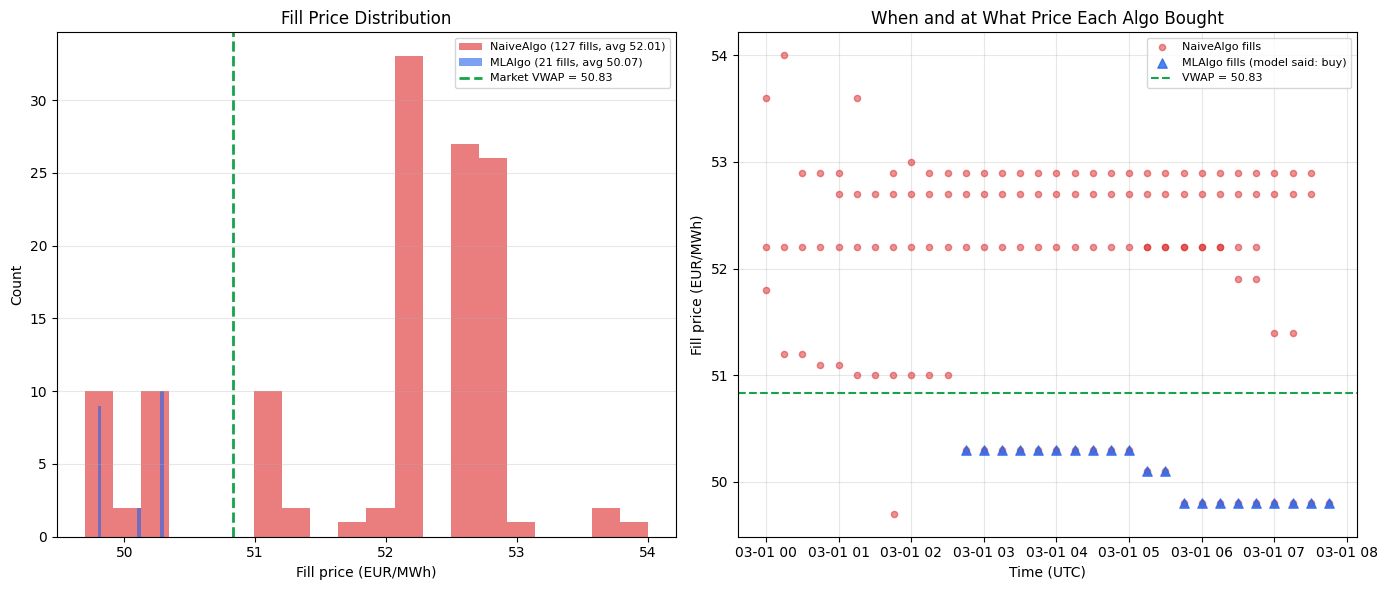

The MLAlgo places fewer orders: it skips bars where the model predicts
the price will be flat or lower. The fill price distribution shows whether
those skipped bars were actually cheaper (which is what we hoped for).


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: fill price histogram
ax1 = axes[0]
if naive_prices:
    ax1.hist(naive_prices, bins=20, color='#dc2626', alpha=0.6,
             label=f'NaiveAlgo ({len(naive_prices)} fills, avg {naive_avg:.2f})')
if ml_prices:
    ax1.hist(ml_prices, bins=20, color='#2563eb', alpha=0.6,
             label=f'MLAlgo ({len(ml_prices)} fills, avg {ml_avg:.2f})')
if vwap:
    ax1.axvline(vwap, color='#16a34a', linewidth=2, linestyle='--',
                label=f'Market VWAP = {vwap:.2f}')
ax1.set_xlabel('Fill price (EUR/MWh)')
ax1.set_ylabel('Count')
ax1.set_title('Fill Price Distribution')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: fills plotted on the price timeline
ax2 = axes[1]
if naive_result.fills:
    naive_times = [f.timestamp for f in naive_result.fills]
    ax2.scatter(naive_times, naive_prices,
                color='#dc2626', alpha=0.5, s=20,
                label='NaiveAlgo fills', zorder=2)
if ml_result.fills:
    ml_times = [f.timestamp for f in ml_result.fills]
    ax2.scatter(ml_times, ml_prices,
                color='#2563eb', alpha=0.8, s=45, marker='^',
                label='MLAlgo fills (model said: buy)', zorder=3)
if vwap:
    ax2.axhline(vwap, color='#16a34a', linewidth=1.5, linestyle='--',
                label=f'VWAP = {vwap:.2f}')
ax2.set_xlabel('Time (UTC)')
ax2.set_ylabel('Fill price (EUR/MWh)')
ax2.set_title('When and at What Price Each Algo Bought')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('The MLAlgo places fewer orders: it skips bars where the model predicts')
print('the price will be flat or lower. The fill price distribution shows whether')
print('those skipped bars were actually cheaper (which is what we hoped for).')

---

## Part 9 — Important Caveats

### 1. Look-ahead bias in feature engineering

Look-ahead bias is the #1 mistake in backtesting ML models for trading. It
happens when a feature includes information that would not have been available
at the time the algo was making its decision.

Common bugs:

| Bug | Why it is wrong |
|---|---|
| `daily_avg = df['price'].mean()` as a feature | The daily average uses prices from the future |
| `df['label'] = df['price'].shift(-5)` without dropping tail rows | Future labels leak into training rows |
| `df['rolling_avg'] = df['price'].rolling(12).mean()` without `shift(1)` | The current bar is included in its own feature |
| Sorting by a future value to create a feature | Any sort that uses information from t+1 onwards |

The same risk applies to signals from `ctx.subscribe_signal()`. The
`publication_offset` parameter prevents this: a forecast for delivery period T
is only visible once the simulated clock reaches T minus the offset.

### 2. Overfitting on a single day

We trained on one day of data: about 270 snapshots across three products. A
linear model generalises well, but any model with more than ~10 parameters
will memorise the training set and fail on new data.

In production: train on at least 3–6 months, validate on the next month (not
a random hold-out), and re-train regularly as market structure evolves.

### 3. Single-feature models are rarely sufficient

`hour_frac` captures the average intraday drift but ignores current liquidity,
recent trade direction, and order book pressure. All of those are available
from `ctx` at runtime. The constraint is simple:

> Every feature used at inference time must be computable from `ctx` methods,
> without accessing data that would not be available at that simulated moment.

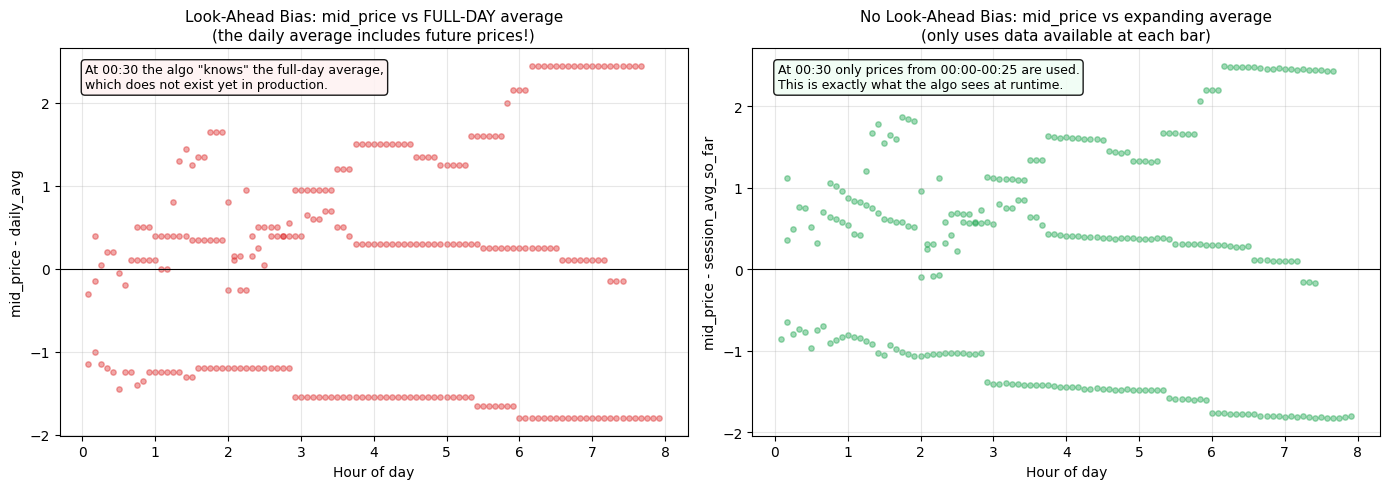

The leaky feature is computed with future knowledge.
A model trained on it learns spurious correlations that vanish in live
trading — the classic look-ahead trap.


In [15]:
# Demonstrate the look-ahead bias trap with a concrete example

# WRONG: the daily average uses prices from the entire session,
# including prices that have not yet occurred in the early-session bars.
daily_avg_leaky = all_snaps['mid_price'].mean()  # includes the future!
all_snaps['feature_leaky'] = all_snaps['mid_price'] - daily_avg_leaky

# RIGHT: expanding mean that only uses data available up to each bar.
# shift(1) ensures the current bar is not included in its own running average.
all_snaps_s = all_snaps.sort_values('timestamp').copy()
all_snaps_s['session_avg'] = (
    all_snaps_s['mid_price']
    .shift(1)       # exclude the current bar
    .expanding()
    .mean()
)
all_snaps_s['feature_clean'] = (
    all_snaps_s['mid_price'] - all_snaps_s['session_avg']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(all_snaps['hour_frac'], all_snaps['feature_leaky'],
            color='#dc2626', alpha=0.4, s=15)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title(
    'Look-Ahead Bias: mid_price vs FULL-DAY average\n'
    '(the daily average includes future prices!)',
    fontsize=11,
)
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('mid_price - daily_avg')
ax1.grid(True, alpha=0.3)
ax1.text(
    0.04, 0.96,
    'At 00:30 the algo "knows" the full-day average,\nwhich does not exist yet in production.',
    transform=ax1.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='#fef2f2', alpha=0.9),
)

ax2 = axes[1]
ax2.scatter(all_snaps_s['hour_frac'], all_snaps_s['feature_clean'],
            color='#16a34a', alpha=0.4, s=15)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title(
    'No Look-Ahead Bias: mid_price vs expanding average\n'
    '(only uses data available at each bar)',
    fontsize=11,
)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('mid_price - session_avg_so_far')
ax2.grid(True, alpha=0.3)
ax2.text(
    0.04, 0.96,
    'At 00:30 only prices from 00:00-00:25 are used.\nThis is exactly what the algo sees at runtime.',
    transform=ax2.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='#f0fdf4', alpha=0.9),
)

plt.tight_layout()
plt.show()

print('The leaky feature is computed with future knowledge.')
print('A model trained on it learns spurious correlations that vanish in live')
print('trading — the classic look-ahead trap.')

---

## Summary

You have built a complete ML pipeline for IDC trading:

| Step | What we did |
|---|---|
| Feature engineering | Replayed the IDC order book at 5-min intervals; extracted `hour_frac`, spread, imbalance |
| Chronological split | Train 00:00–04:00, test 04:00–07:30 — never shuffle a time series |
| Model training | `LinearRegression` predicting the next 5-min mid-price from `hour_frac` |
| ONNX export | `skl2onnx` converts the fitted model to a portable `.onnx` file |
| Registration | `ONNXModel` + `ModelRegistry` + `validate_all()` to catch issues early |
| Algo integration | `ctx.predict()` in `on_bar()` — same interface in backtest and live |
| Backtest comparison | Naive (always buy) vs ML (buy only when model says so) |

### Where to go next

- **Add features**: `spread_eur_mwh` and `time_to_gate_mins` are already
  computed in `build_snapshots()` and available from `ctx` at runtime
- **Use more data**: months of IDC history instead of one day
- **Non-linear models**: gradient boosting or a small neural net, exported
  to ONNX with descriptive input/output names
- **Validate before running**: `nexa validate my_algo.py --model idc_price_model:models/idc.onnx`
  catches file-not-found and schema errors before the backtest starts

### The key principle

> The algo never knows whether it is in backtest or production.
> It calls `ctx.predict()`, gets a dict, and makes a decision.
> The engine — and the validation pipeline — handle everything else.

---

*Next: Notebook 07 — Multi-Algo Shared Data Replay*